### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP2: Principal components regression in genetics

The goal of this TP session is to use genetic markers to predict the geographical origin of a set of indians from South, Central, and North America. We propose to build two regression linear models to predict the latitude and longitude of an individual based on its genetic markers. Because the number of markers (p = 5709) is larger than the number of samples (N = 494), the predictors of the regression model will be the outputs of a principal component analysis (PCA) performed on the genetic markers. A genetic marker is encoded 1 if the individual has a mutation, 0 elsewhere.

## ▶️ Exercise 1: Data visualization (1 point)

NB: To do this exercise you will have to install packages `geopandas` and `geodatasets`.

Download dataset `NAm2.txt` from [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP2/NAm2.txt). Each row of the dataset corresponds to an individual and the columns have explicit names. The third column contains the names of the tribes to which each individual pertains. Columns 7 and 8 contain the latitude and the longitude and from Column 9 onwards are genetic markers, which are encoded are 0 or 1. Run the code described below and explain how it works.

```
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()
```

/tmp/ipykernel_6436/1004039095.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


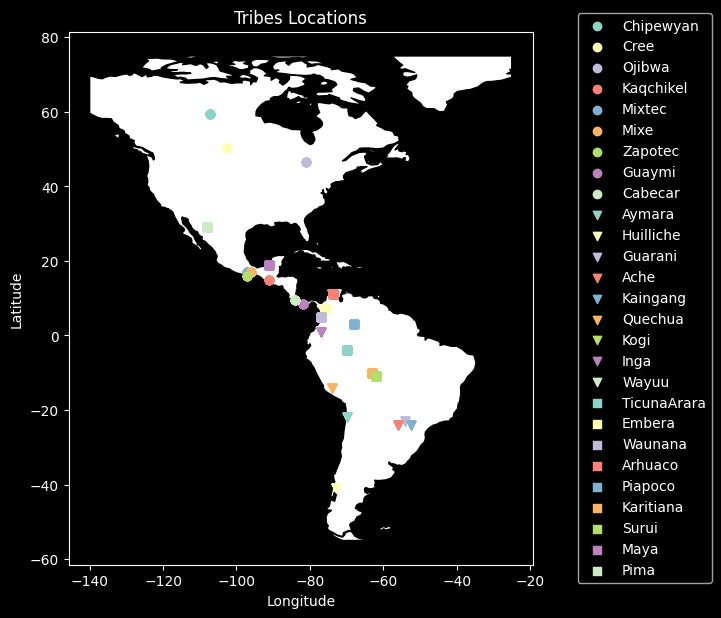

In [1]:
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'],
               marker=marker_list[i//9],
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

The code extracts the latitude and longitude from the file NAm2.txt. With geodatasets.get_path('naturalearth.land') we generate a map of the world (America with the .clip). For every tribe, the code put a marker on the map (marker_list[i//9] and colors_list[i%9]), with a legend.

## ▶️ Exercise 2: Multiple linear regression (2 points)

Using **only** the genetic markers as predictors, you will estimate a multiple linear regression model to predict the longitude of each individual.

You will proceed in several steps.

**(a)** First, try to estimate the coefficients of the multiple linear regression using the expression seen in class 

$$\hat{\beta} = (X^\top X)^{-1}X^\top y$$

You should proceed as we did in TP1 using `numpy.linalg.solve` to obtain the values of $\beta$. 

Did you run into any errors? What is going on? Relate your answer to the fact that $\text{rank}(X) < p$, where $X \in R^{N*p}$ is the data matrix.

In [6]:
import numpy as np

y = df.iloc[:, 7].values
X = df.iloc[:, 8:].values

XtX = X.T @ X
Xty = X.T @ y

try:
    beta = np.linalg.solve(XtX, Xty)
except Exception as e:
    print(f"Error encountered: {type(e).__name__} - {e}")


Error encountered: LinAlgError - Singular matrix


We had the error : LinAlgError - Singular matrix. The matrix $X^\top X$ is singular and cannot be inverted. The design matrix $X \in \mathbb{R}^{494 \times 5709}$, and the rank of a matrix cannot exceed its smallest dimension, therefore $\text{rank}(X) \le \min(494, 5709) = 494$. Also, $\text{rank}(X^\top X) = \text{rank}(X)$, which implies that the maximum rank of the $p \times p$ ($5709 \times 5709$) square matrix $X^\top X$ is also 494. For $X^\top X$ to be invertible, its rank must be 5709. Because $494 \ll 5709$, the matrix is impossible to invert.

**(b)** Use function `numpy.linalg.lstsq` to estimate the coefficients (it may take a few seconds to get a result). 

And now? Did you get any errors? Why is that? 

Relate your answer to the difference between functions `numpy.linalg.solve` and `numpy.linalg.lstsq`.

You can check the documention for both functions as well as [this](https://netlib.org/lapack/lug/node27.html) link for more information.

In [10]:
beta_lstsq, residuals, rank, s = np.linalg.lstsq(X, y, rcond=None)

print("First 5 coefficients: ")
print(beta_lstsq[:5])
print("Shape: ", beta_lstsq.shape)

First 5 coefficients: 
[-0.04005781 -0.01940898  0.01111306 -0.01234685 -0.02460976]
Shape:  (5709,)


Unlike `numpy.linalg.solve`, which requires a full-rank matrix, `numpy.linalg.lstsq` does not attempt a direct matrix inversion, but relies on the SVD of X to compute the inverse. It returns the solution $\hat{\beta}$ that has the smallest possible $L_2$ norm ($||\hat{\beta}||_2$).

 **(c)** We will now use `sklearn` to do our linear regression with the help of class `sklearn.linear_model.LinearRegression` whose documentation is available [here](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html). Note that every estimator from `sklearn` has a `fit` and a `predict` method, which are used to calculate coefficients and predict values (see [here](https://scikit-learn.org/stable/getting_started.html#fitting-and-predicting-estimator-basics) for more info). In our current case, we can do:

```
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
```

You should not run into errors now, since `sklearn` also uses `lstsq` to solve the normal equations, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L682) (though it uses the `scipy` implementation instead of the `numpy` for "historical" reasons). Check the values of the estimated coefficients stored as an attribute in `lr.coef_`, are they the same as the ones obtained in item **(b)**? Probably not. This is because `sklearn` re-centers the predictors before estimating the coefficients of the linear regression, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L622). What would be a practical reason for doing such re-centering systematically? Hint: it has to do with how to interpret the intercept of the model. 

In [13]:
from sklearn.linear_model import LinearRegression

# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
lr.coef_

array([-0.03940988, -0.0245272 ,  0.01089763, ...,  0.04804479,
       -0.08985062,  0.01903025], shape=(5709,))

Mean-centering the predictors ensures that the expected value of each feature becomes zero. The intercept $\beta_0$ of the linear model is interpreted as the mean $\bar{y}$. An uncentered intercept represents the expected value of $y$ when all predictors are strictly zero, a scenario that is often physically meaningless or far outside the observed data domain.

## ▶️ Exercise 3: Principal components analysis (5 points)

**(a)** Explain in a few words the main concepts and ideas underlying the principal component analysis (PCA). You should include both the geometric and statistical interpretations of PCA.

PCA is a statistical dimensionality reduction technique that transforms a dataset into a new set of linearly uncorrelated variables, ordered such that the first few components maximize the retained variance of the original data. Geometrically, this process corresponds to finding a sequence of orthogonal axes that minimizes the mean squared distance between the original data points and their orthogonal projections onto this new lower-dimensional subspace.

**(b)** Use the estimator defined in `sklearn.decomposition.PCA` to do a PCA on the dataset. Plot the first two dimensions of the projected data points on a scatterplot. The scattered points should have different markers and colors depending on which tribe they belong to. You can use the same color/marker style from **Exercise 2** or propose a new one.

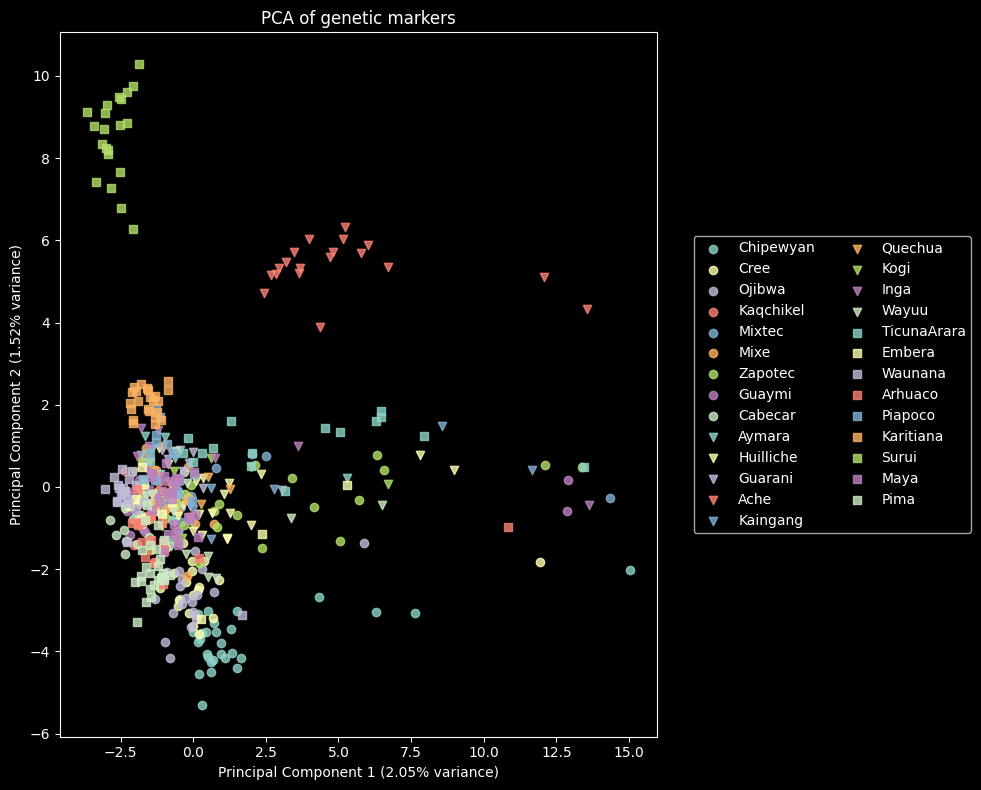

In [22]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plot_df = pd.DataFrame({
    'Pop': df['Pop'],
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1]
})

fig, ax = plt.subplots(figsize=(10, 8))
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
unique_tribes = df['Pop'].unique()

for i, tribe in enumerate(unique_tribes):
    members = plot_df[plot_df['Pop'] == tribe]
    ax.scatter(members['PC1'], members['PC2'],
               marker=marker_list[i // 9],
               color=colors_list[i % 9],
               label=tribe,
               alpha=0.8)
ax.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), ncol=2)
ax.set_title('PCA of genetic markers')

var_explained = pca.explained_variance_ratio_ * 100
ax.set_xlabel(f'Principal Component 1 ({var_explained[0]:.2f}% variance)')
ax.set_ylabel(f'Principal Component 2 ({var_explained[1]:.2f}% variance)')
plt.tight_layout()
plt.show()

**(c)** Remember from our class that the results of PCA are affected when pre-processing transformations are applied to the data. We will illustrate this using `sklearn.preprocessing.StandardScaler` as per:
```
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
```
Redo the 2D scatter plot from item **(b)** on the normalized version of the datast. How does it compare to your previous plot?

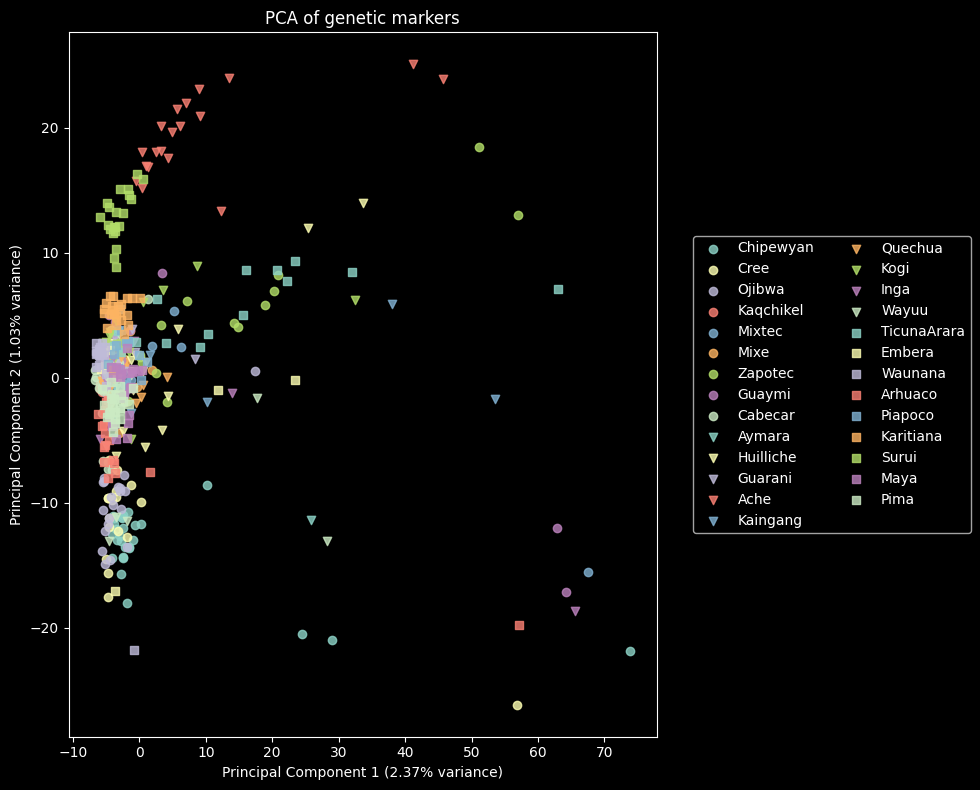

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)

pca_std = PCA(n_components=2)
X_pca_std = pca_std.fit_transform(X_std)
plot_df = pd.DataFrame({
    'Pop': df['Pop'],
    'PC1': X_pca_std[:, 0],
    'PC2': X_pca_std[:, 1]
})

fig, ax = plt.subplots(figsize=(10, 8))
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
unique_tribes = df['Pop'].unique()

for i, tribe in enumerate(unique_tribes):
    members = plot_df[plot_df['Pop'] == tribe]
    ax.scatter(members['PC1'], members['PC2'],
               marker=marker_list[i // 9],
               color=colors_list[i % 9],
               label=tribe,
               alpha=0.8)
ax.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), ncol=2)
ax.set_title('PCA of genetic markers')

var_explained = pca_std.explained_variance_ratio_ * 100
ax.set_xlabel(f'Principal Component 1 ({var_explained[0]:.2f}% variance)')
ax.set_ylabel(f'Principal Component 2 ({var_explained[1]:.2f}% variance)')
plt.tight_layout()
plt.show()


**(d)** Given the results in **(b)** and **(c)**, what can you conclude regarding the necessity of standardizing the data points for the dataset consider in this TP?

Here, standardizing the data is not necessary and is actually detrimental to the analysis. Standardizing binary data forces extremely rare mutations to exhibit the same variance as common ones, which amplifies noise and distorts the population clusters by introducing extreme outliers along the first principal component (as we can see in the (c) graph). Therefore, the unstandardized PCA provides a much more coherent representation of the tribes' genetic structure.

**(e)** Which percentage of variance is captured by the first two principal components? How many principal components would you keep if you would like to represent the genetic markers using a minimal number of principal components? To help answering this question, you can use a plot showing the cumulative percentage of variance as a function of the number of principal components.

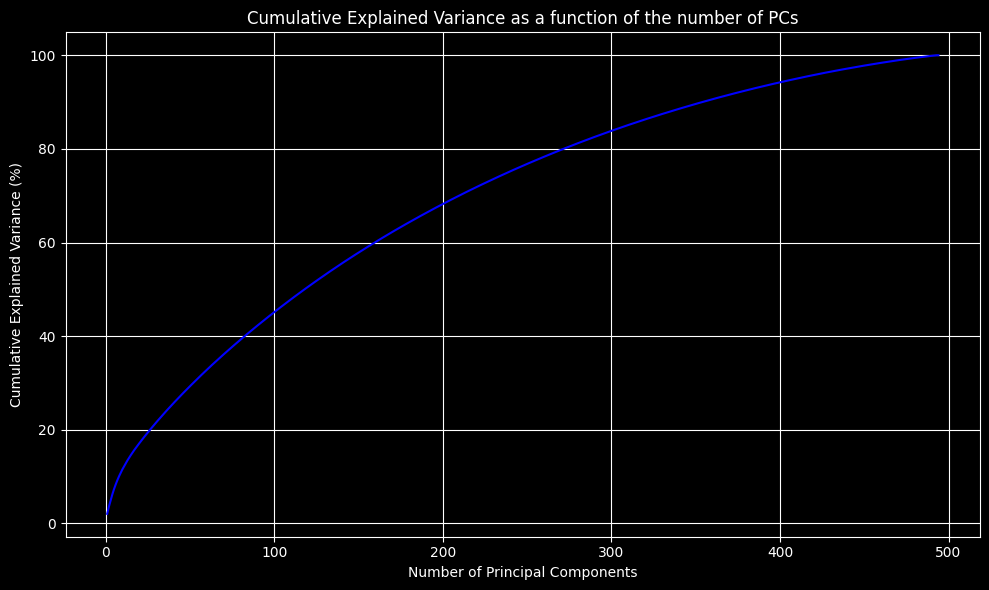

Explained Variance PC1 : 2.05%
Explained Variance PC2 : 1.52%
Total : 3.57%


In [24]:
pca_full = PCA()
pca_full.fit(X)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_) * 100
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='', linestyle='-', color='b')
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('Cumulative Explained Variance as a function of the number of PCs')
ax.grid(True)
plt.tight_layout()
plt.show()

var_pc1 = pca_full.explained_variance_ratio_[0] * 100
var_pc2 = pca_full.explained_variance_ratio_[1] * 100
print(f"Explained Variance PC1 : {var_pc1:.2f}%")
print(f"Explained Variance PC2 : {var_pc2:.2f}%")
print(f"Total : {var_pc1 + var_pc2:.2f}%")

To capture an acceptable threshold such as $80\%$ of the total variance, we would need to retain approximately $275$ PCs. This high number indicates that the genetic information is inherently high-dimensional and broadly distributed across many markers rather than being concentrated in just a few main axes.

## ▶️ Exercise 4: Principal components regression (4 points)

**(a)** Predict the latitude and the longitude of all points from the dataset using the scores of the first 250 PCA axes. Plot the predicted spatial coordinates using the same style and structure from **Exercise 1** and compare the results from each plot. What can you conclude? Does the new map illustrate somehow too optimistically (or too pessimistically) the ability to find geographical origin of individuals outside the database from its genetic markers? Justify your answer.

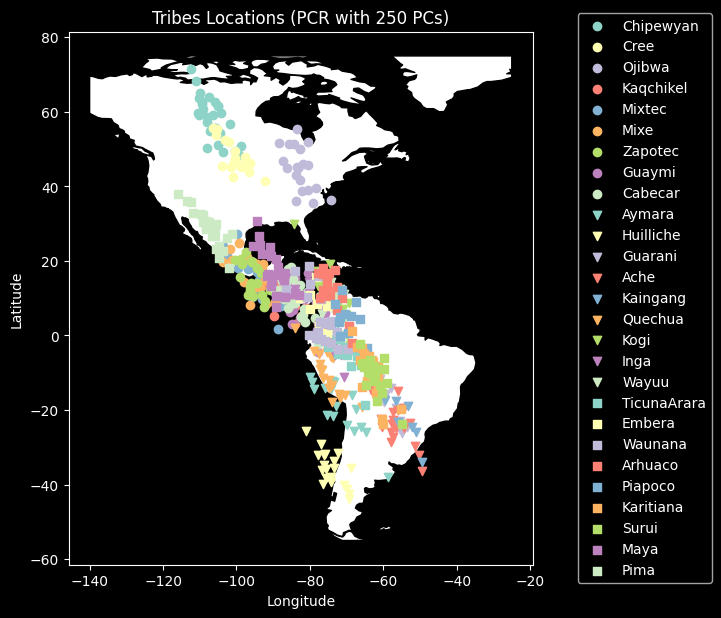

In [29]:
pca_250 = PCA(n_components=250)
X_pcr = pca_250.fit_transform(X)

latitude = df['lat'].values
longitude = df['long'].values

lr_lat = LinearRegression()
lr_lat.fit(X_pcr, latitude)
lat_pred = lr_lat.predict(X_pcr)

lr_long = LinearRegression()
lr_long.fit(X_pcr, longitude)
long_pred = lr_long.predict(X_pcr)

df_pred = df.copy()
df_pred['lat_pred'] = lat_pred
df_pred['long_pred'] = long_pred

gdf_pred = gpd.GeoDataFrame(df_pred, geometry=gpd.points_from_xy(df_pred['long_pred'], df_pred['lat_pred']))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf_pred['Pop'].unique()):
    members_tribe = gdf_pred[gdf_pred['Pop'] == tribe]
    ax.scatter(members_tribe['long_pred'], members_tribe['lat_pred'],
               marker=marker_list[i//9],
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations (PCR with 250 PCs)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

The new map illustrates the model's predictive ability far too optimistically. The regression uses $250$ principal components to fit only $494$ individuals and is evaluated on the exact same data used for training, so it is overfitting. Its performance on individuals outside this specific database would likely be  worse, as the model has essentially memorized the training set's geographical coordinates rather than learning a generalizable biological rule.

**(b)** Quantify the error of the linear regression model using the mean distance between real and predicted coordinates. Beware to use `sklearn.metrics.pairwise.haversine_distances` so to correctly measure the distances between points so to take into account the curvature of the Earth. Your answer should be given in kilometers.

In [31]:
from sklearn.metrics.pairwise import haversine_distances

true_coords = np.column_stack((latitude, longitude))
pred_coords = np.column_stack((lat_pred, long_pred))
true_coords_rad = np.radians(true_coords)
pred_coords_rad = np.radians(pred_coords)

dist_matrix = haversine_distances(true_coords_rad, pred_coords_rad)
paired_dist = np.diag(dist_matrix)

EARTH_RADIUS = 6371.01
errors_km = paired_dist * EARTH_RADIUS

mean_error = np.mean(errors_km)
print(f"Mean error is {mean_error:.2f} km")

Mean error is 623.62 km


## ▶️ Exercise 5: PCR and cross-validation (6 points)

Our goal now is to build the best model to predict individual geographical coordinates. 

For this, you will run a linear regression to predict latitudes and longitudes. Note that `sklearn.linear_model.LinearRegression` can naturally handle the fact of having two sets of coefficients. We will use ten-fold cross-validation to helps us choose the number of principal axes that we should keep. You should report the errors in terms of kilometers as done in **Exercise 4(b)**.

**(a)** Recall in a few words the principle of cross-validation. Explain why this procedure is useful when building a predictive model. Your answer should mention different strategies to handle datasets in which the samples are not IID.

Cross-validation is used to evaluate a predictive model's generalization capability by separating the dataset into training and validation sets, detecting overfitting. When the samples are not IID, standard random splitting is flawed; instead, specialized procedures such as grouped cross-validation (which keeps correlated samples, like individuals from the same tribe, strictly within the same fold) or stratified cross-validation must be employed to prevent data leakage and ensure realistic performance estimates.

**(b)** Based on the structure of the dataset being used, such as the different countries of the individuals and the order in which the rows of the dataframe are provided, explain which choice of cross-validation iterator from [here](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators) seems the most adequate for our context.

Because the dataset rows are ordered by population and individuals from the same tribe share correlated genetic structures (violating the IID assumption), a standard cross-validation would fail by isolating entire geographic regions into single folds. Therefore, the most adequate iterator is `GroupKFold` (using the tribes as groups), which prevents data leakage between related individuals and evaluates the model's true capability to generalize its geographic predictions to unseen populations.

**(c)** We first assess the quality of the PCR fit for `n_components=4`. Note that you should be careful in avoiding [data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage) problems when doing the PCA followed by a multiple linear regression. You should use the pipeline interface from scikit-learn with `sklearn.pipeline.make_pipeline` to facilitate your task. Be sure to evaluate the errors as done in **Exercise 4(b)**.

In [32]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GroupKFold, cross_val_predict

X = df.iloc[:, 8:].values
y = df[['lat', 'long']].values
groups = df['Pop'].values

pcr_pipeline = make_pipeline(PCA(n_components=4), LinearRegression())
cv = GroupKFold(n_splits=10)

y_pred_cv = cross_val_predict(pcr_pipeline, X, y, cv=cv, groups=groups)

true_coords_rad = np.radians(y)
pred_coords_rad = np.radians(y_pred_cv)

dist_matrix = haversine_distances(true_coords_rad, pred_coords_rad)
paired_dist = np.diag(dist_matrix)

EARTH_RADIUS = 6371.01
errors_km = paired_dist * EARTH_RADIUS

mean_error_4pc = np.mean(errors_km)
print(f"Mean error is {mean_error_4pc:.2f} km")

Mean error is 2168.89 km


**(d)** Repeat the analysis from item **(b)** but changing `n_components` between 2 and 440 in steps of 10. Plot the mean training and test errors versus the number of principal components. Attention, the errors should be given in kilometers.

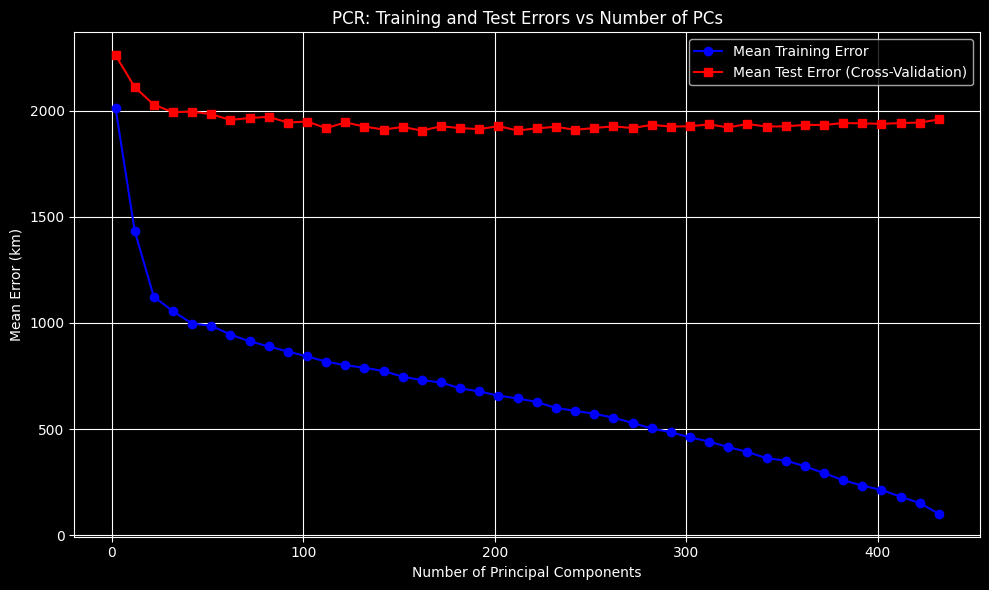

In [33]:
X = df.iloc[:, 8:].values
y = df[['lat', 'long']].values
groups = df['Pop'].values

n_components_list = np.arange(2, 442, 10)
mean_train_errors = []
mean_test_errors = []
gkf = GroupKFold(n_splits=10)

for n_components in n_components_list:
    train_errors = []
    test_errors = []
    for train_index, test_index in gkf.split(X, y, groups=groups):
        X_train, X_test = X[train_index], X[test_index]
        Y_train, Y_test = y[train_index], y[test_index]
        pca = PCA(n_components=n_components)
        X_train_pca = pca.fit_transform(X_train)
        X_test_pca = pca.transform(X_test)

        lr = LinearRegression()
        lr.fit(X_train_pca, Y_train)
        y_train_pred = lr.predict(X_train_pca)
        y_test_pred = lr.predict(X_test_pca)

        dist_train = np.diag(haversine_distances(np.radians(Y_train), np.radians(y_train_pred)))
        train_errors.append(np.mean(dist_train) * 6371.0)

        dist_test = np.diag(haversine_distances(np.radians(Y_test), np.radians(y_test_pred)))
        test_errors.append(np.mean(dist_test) * 6371.0)

    mean_train_errors.append(np.mean(train_errors))
    mean_test_errors.append(np.mean(test_errors))

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(n_components_list, mean_train_errors, label='Mean Training Error', marker='o', color='blue')
ax.plot(n_components_list, mean_test_errors, label='Mean Test Error (Cross-Validation)', marker='s', color='red')

ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Mean Error (km)')
ax.set_title('PCR: Training and Test Errors vs Number of PCs')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

**(e)** Which model would you keep? What is the prediction error for this model? Compare it with its corresponding training error. Plot the predicted coordinates on a map as in **Exercise 4(a)**. What can you conclude?

Based on the cross-validation results, I would keep the model with the number of principal components that minimizes the mean test error, which is $160$ components. The cross-validation prediction error is $1900$ km, which remains higher than its corresponding training error of about $700$ km. We can conclude that despite using the optimal number of components, the noise in the genetic data and the complexity of human migration limit the model's true predictive accuracy, resulting in a map where predicted locations are far more scattered and less precise than the overfitted model from the previous exercise.

Optimal number of PCs: 162
Prediction Error (CV): 1905.60 km
Training Error: 730.27 km


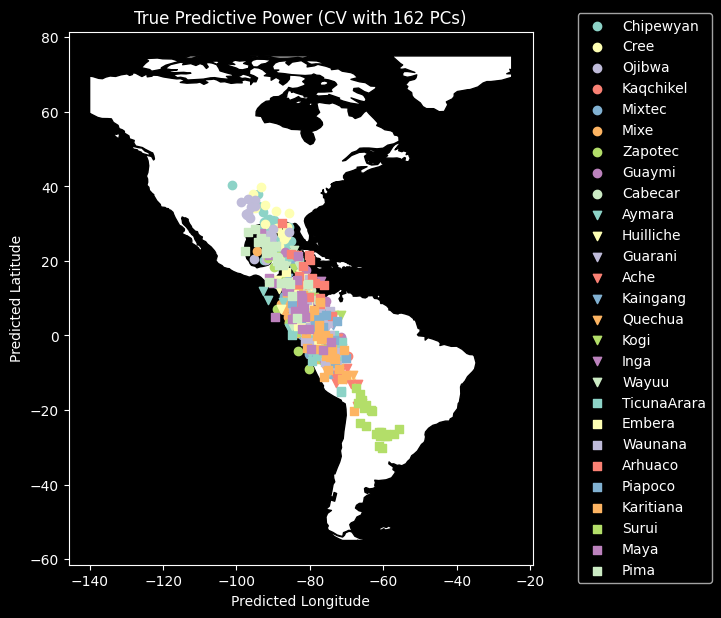

In [34]:
optimal_idx = np.argmin(mean_test_errors)
best_n = n_components_list[optimal_idx]
best_test_error = mean_test_errors[optimal_idx]
best_train_error = mean_train_errors[optimal_idx]

print(f"Optimal number of PCs: {best_n}")
print(f"Prediction Error (CV): {best_test_error:.2f} km")
print(f"Training Error: {best_train_error:.2f} km")

pcr_pipeline_opt = make_pipeline(PCA(n_components=best_n), LinearRegression())
y_pred_cv_opt = cross_val_predict(pcr_pipeline_opt, X, y, cv=gkf, groups=groups)

df_pred_opt = df.copy()
df_pred_opt['lat_pred'] = y_pred_cv_opt[:, 0]
df_pred_opt['long_pred'] = y_pred_cv_opt[:, 1]
gdf_pred_opt = gpd.GeoDataFrame(
    df_pred_opt,
    geometry=gpd.points_from_xy(df_pred_opt['long_pred'], df_pred_opt['lat_pred'])
)

world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')

marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

for i, tribe in enumerate(gdf_pred_opt['Pop'].unique()):
    members_tribe = gdf_pred_opt[gdf_pred_opt['Pop'] == tribe]
    ax.scatter(members_tribe['long_pred'], members_tribe['lat_pred'],
               marker=marker_list[i//9],
               color=colors_list[i%9], label=tribe)

ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title(f'True Predictive Power (CV with {best_n} PCs)')
ax.set_xlabel('Predicted Longitude')
ax.set_ylabel('Predicted Latitude')
plt.show()

Unlike the overfitted model, these cross-validated predictions are scattered and regress towards the continental mean, illustrating the high prediction error of  $1905$ km. This concludes that a simple linear combination of these genetic markers is insufficient for the precise geographical localization of populations outside the training database.

## ▶️ Exercise 6: Conclusion (2 points)

Propose a conclusion to your study. You can write a paragraph about the quality of predictors versus the number of factors, possible improvements to the approach (for instance, showing what happens when using [partial least squares](https://scikit-learn.org/1.5/auto_examples/cross_decomposition/plot_pcr_vs_pls.html) instead of PCR), comment on the performance of the regression in predictions for each country separately, etc. Note that we expect a thorough presentation of the final predictive model as well as an interpretation of it, not simply a bunch of `python` code lines.

In this study, we tried to predict the geographical coordinates of Native American populations using their genetic markers. Our first PCR model with $250$ components looked perfect, but cross-validation showed it was just overfitting. Using a `GroupKFold` strategy, we found that the best model needs $162$ components. However, the prediction error is still high (about $1900$ km). We conclude that while genetic markers show broad North-South migration patterns, a simple linear model cannot find the exact local origin of unseen individuals.


Predicting with this genetic dataset is difficult because the markers are binary and the variance is very spread out. The first two components capture less than $4\%$ of the variance. Because of this, we have to use many components to get enough information. This creates a problem: using too few components leads to underfitting, while using too many introduces noise and leads to overfitting on new tribes.


A big limitation of PCR is that PCA is an unsupervised method. It only looks at the variance in the genetic data ($X$) and ignores the geographical coordinates ($y$). A good way to improve this would be to use Partial Least Squares (PLS) regression. PLS is supervised, meaning it tries to maximize the relationship between $X$ and $y$. If we used PLS, we could probably get a similar or lower error with much fewer components, making the model stronger and less likely to overfit.


Finally, the prediction error is not the same for all countries. The model is better at finding populations at the extreme North or South of the map. However, for populations close together in Central America or the Amazon, the predictions overlap too much and tend to group in the middle. This shows that recent migrations and complex local histories cannot be perfectly captured by a simple linear model.